### Import libraries and define functions

In [1]:
import numpy as np
import torch
from torch.distributions import HalfNormal, Uniform, Normal
from scipy import stats
from sbi.utils import BoxUniform, MultipleIndependent, mcmc_transform
from sbi.neural_nets import posterior_nn, likelihood_nn
import scipy
from sbi.inference import NPE, MCMCPosterior, posterior_estimator_based_potential, simulate_for_sbi
from sbi.neural_nets.embedding_nets import FCEmbedding, CNNEmbedding, PermutationInvariantEmbedding, ResNetEmbedding1D
from matplotlib import pyplot as plt
from sbi.analysis import pairplot, plot_summary
import pandas as pd
import corner
from sbi.inference import NLE_A, NRE_A, NRE_B, NRE_C, NPE_C, NPE_A

/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define simulator parameters
f_low = 10
f_high = 200
fref  = 25
pi = np.pi
sqrt = np.sqrt
H100 = 3.241e-18
h    = 0.679
H0   = h * H100
T_obs = 365 * 24 * 3600
Delta_f = 1/32.
N_bins = int((f_high - f_low) / Delta_f) + 1
freq = np.linspace(f_low, f_high, N_bins)   
psd = np.genfromtxt("data/cosmic_explorer_40km_for_paper.txt")
psd[0, 0]  = 4.99999999999999999
psd[:, 1] = psd[:, 1]**2
gamma = np.genfromtxt("data/gamma_HL.txt")
# Interpolations
psd_interp = scipy.interpolate.interp1d(psd[:, 0], psd[:, 1], fill_value="extrapolate")
gamma_interp = scipy.interpolate.interp1d(gamma[:, 0], gamma[:, 1], fill_value="extrapolate")
psd_vals = psd_interp(freq)
gamma_vals = gamma_interp(freq)

In [3]:
numerator = (20 * np.pi**2 * freq**3)**2 * psd_vals**2
denominator = (3 * H0**2)**2 * 8 * gamma_vals**2
T = 1 / (freq[1] - freq[0])
N = int( T_obs // T )
sigma = np.sqrt(numerator / denominator / N)

In [4]:
prior = MultipleIndependent( [HalfNormal(torch.tensor([1.0])),  # scaled Ω

        Normal(torch.tensor([0.0]), torch.tensor([1.0]))]
                            ,validate_args=False)

In [5]:
def simulate_physical(theta_scaled):
    """
    Generate noisy power spectra given physical parameters.
    This is the *true* generative model used to train SBI.
    """
    #theta_scaled = torch.as_tensor(theta_scaled, dtype=torch.float32)

    omega_scaled = theta_scaled[:, 0] # unconstrained N(0,1)
    alpha        = theta_scaled[:, 1]    # unconstrained
    Omega_ref = 1e-11*(omega_scaled) 
    Omega_ref =Omega_ref[:, None] 
    alpha_term = torch.tensor(freq / fref)[None, :] ** alpha[:, None]

    # True model
    C_true = Omega_ref * alpha_term

    # Add noise (Gaussian)
    rng = np.random.default_rng()
    C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)

    # compute optimal summaries
   # summaries = optimal_summaries(C_noisy, sigma, freq, gamma_vals, alpha)

    return torch.tensor(C_noisy, dtype=torch.float32)
    
def simulate_multi(theta_scaled, M=10):
    """
    Generate noisy power spectra given physical parameters.
    This is the *true* generative model used to train SBI.
    """
    #theta_scaled = torch.as_tensor(theta_scaled, dtype=torch.float32)
    omega_scaled =  theta_scaled[0]  # unconstrained N(0,1)
    alpha        = theta_scaled[ 1]    # unconstrained
    Omega_ref = 1e-11*(omega_scaled) 
    Omega_ref =Omega_ref
    alpha_term = torch.tensor(freq / fref)** alpha

    # True model
    C_true = Omega_ref * alpha_term

    # Add noise (Gaussian)
    rng = np.random.default_rng()
    C_noisy = C_true +  rng.normal(0, sigma, size=(M,len(freq)))
    # compute optimal summaries
   # summaries = optimal_summaries(C_noisy, sigma, freq, gamma_vals, alpha)

    return torch.tensor(C_noisy, dtype=torch.float32)
    #C_noisy = np.maximum(C_noisy, 0.0)
    
def simulate_multi_no_noise(theta_scaled, M=10):
    """
    Generate noisy power spectra given physical parameters.
    This is the *true* generative model used to train SBI.
    """
    #theta_scaled = torch.as_tensor(theta_scaled, dtype=torch.float32)
    omega_scaled =  theta_scaled[0]  # unconstrained N(0,1)
    alpha        = theta_scaled[ 1]    # unconstrained
    Omega_ref = 1e-11*(omega_scaled) 
    Omega_ref =Omega_ref
    alpha_term = torch.tensor(freq / fref)** alpha

    # True model
    C_true = Omega_ref * alpha_term

    # Add noise (Gaussian)
   # rng = np.random.default_rng()
    #C_noisy = C_true +  rng.normal(0, sigma, size=(M,len(freq)))
    # compute optimal summaries
   # summaries = optimal_summaries(C_noisy, sigma, freq, gamma_vals, alpha)

    return torch.tensor(C_true, dtype=torch.float32)
    #C_noisy = np.maximum(C_noisy, 0.0)
    
def simulator_no_noise(theta_scaled):
    """
    Generate noisy power spectra given physical parameters.
    This is the *true* generative model used to train SBI.
    """
    #theta_scaled = torch.as_tensor(theta_scaled, dtype=torch.float32)

    omega_scaled = theta_scaled[:, 0] # unconstrained N(0,17
    alpha        = theta_scaled[:, 1]    # unconstrained
    Omega_ref = 1e-11*(omega_scaled) 
    Omega_ref =Omega_ref[:, None]
    alpha_term = torch.tensor(freq / fref)[None, :] ** alpha[:, None]

    # True model
    C_true = Omega_ref * alpha_term

    return torch.tensor(C_true, dtype=torch.float32)

In [6]:
def credible_interval(vals, pdf, frac=0.68):
    cdf = np.cumsum(pdf)
    cdf /= cdf[-1]
    lo = np.searchsorted(cdf, (1-frac)/2)
    hi = np.searchsorted(cdf, 1-(1-frac)/2)
    return vals[lo], vals[hi]



### Create and save observations and training data 

In [7]:
#import torch

omegas = torch.tensor([1, 0.1, 0.01, 0.003])   # choose Ω values
alphas = torch.tensor([-1.0, 0.0, 1, 1.5])        # choose α values


dataset = {}

for omega in omegas:
    for alpha in alphas:

        observations = []

        theta = torch.tensor([[omega, alpha]])
        x = simulate_physical(theta)
        observations.append(x)

        #observations = torch.stack(observations)

        dataset[(float(omega), float(alpha))] = observations
        torch.save(dataset, "simulated_dataset.pt")
        
print("Saved dataset to simulated_observations.pt")


Saved dataset to simulated_observations.pt


/local/lexi.leali/ipykernel_1769837/416138087.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_1769837/416138087.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)


In [8]:

M = 10#number of noise realizations for each theta
theta = prior.sample((5000,))

x_all = []
theta_all = []

for theta_i in theta:

    x_multi = simulate_multi(theta_i, M)
    theta_rep = theta_i.repeat(M,1)

    x_all.append(x_multi)
    theta_all.append(theta_rep)

x_train = torch.vstack(x_all)
theta_all = torch.vstack(theta_all)
# ---------------------------------------------------

torch.save(
{
    "simulated_x":x_train,
    "theta": theta_all,
   
},
"training_data.pt"
)


#x_train= torch.tensor(x_train / sigma, dtype=torch.float32)
#x_train = torch.sign(x_train) * torch.log10(1 + torch.abs(x_train))
#x_train = compute_summaries(freq, x_train)

/local/lexi.leali/ipykernel_1769837/416138087.py:43: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true +  rng.normal(0, sigma, size=(M,len(freq)))
/local/lexi.leali/ipykernel_1769837/416138087.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)


In [9]:
## load desired observation
data = torch.load("simulated_observations.pt")

x = data["x"]
theta = data["theta"]

/local/lexi.leali/ipykernel_1769837/2001095183.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("simulated_observations.pt")


In [10]:
x_obs = x[4,:]
theta_true = theta[4]

In [11]:
theta_true

tensor([[0.1000, 0.0000]])

In [12]:
data = torch.load("training_data.pt")

x_train = data["simulated_x"]
theta_all = data["theta"]

/local/lexi.leali/ipykernel_1769837/505472112.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("training_data.pt")


In [13]:
data

{'simulated_x': tensor([[ 1.1491e-11,  1.3505e-11,  4.4393e-12,  ..., -3.1832e-08,
          -2.6366e-08, -6.5372e-09],
         [ 6.7695e-12,  1.1568e-11,  5.5375e-13,  ...,  3.8444e-08,
          -8.9107e-08, -9.2181e-08],
         [ 1.3307e-11,  1.0636e-11,  9.0598e-12,  ..., -1.9724e-07,
           1.7728e-07, -1.9036e-07],
         ...,
         [ 7.4590e-12,  1.0014e-11,  9.9619e-12,  ...,  1.5186e-08,
           6.8333e-09,  9.0473e-08],
         [ 4.7708e-12,  4.8588e-12,  5.7013e-12,  ..., -9.3885e-08,
          -3.7795e-09, -7.5590e-08],
         [ 2.1949e-12,  6.9761e-12,  8.8385e-12,  ...,  4.3470e-08,
           3.4469e-09, -6.1112e-08]]),
 'theta': tensor([[ 0.8353, -0.0681],
         [ 0.8353, -0.0681],
         [ 0.8353, -0.0681],
         ...,
         [ 0.2298, -1.0869],
         [ 0.2298, -1.0869],
         [ 0.2298, -1.0869]])}

In [14]:
from scipy.special import logsumexp

### Compute likelihood on a grid

In [15]:
alpha_vals = np.linspace(-3, 3, 500)             # α grid
Omega_vals = np.linspace(0, 3, 1_000)   # scaled  Ω grid
prior_alpha = Normal(loc =torch.tensor(0.0, dtype=torch.float32), scale=torch.tensor(1.0, dtype=torch.float32))
prior_Omega = HalfNormal(
                      torch.tensor(1.0, dtype=torch.float32))
batch_size = 500

def grid_eval( x_obs):
    M = len(Omega_vals)
    K = len(alpha_vals)
    Omega_scaled = Omega_vals         
    # Make full (M,K,2) grid of parameters in simulator units
    Omega_mesh, alpha_mesh = np.meshgrid(Omega_scaled, alpha_vals, indexing="ij")
    theta_grid = np.stack([Omega_mesh, alpha_mesh], axis=-1).reshape(-1, 2)
    theta_torch = torch.tensor(theta_grid)

    logpost_list = []
    
    for i in range(0, N, batch_size):
        #print(i)
        batch = theta_torch[i:i+batch_size]
    
        # Simulator output: must be NO-NOISE
        out = simulator_no_noise(batch)
        # x_obs: observed clipped data shape (D,) or (B, D) if multiple obs

        logL = -0.5 * torch.sum(((x_obs - out) / sigma)**2, dim=1)

        # Prior in SIMULATOR SPACE (very important!)
        logP = prior_Omega.log_prob(batch[:,0]) + prior_alpha.log_prob(batch[:,1])
       # print(prior_Omega.log_prob(batch[:,0]))
        # Posterior
        logpost_list.append((logL+logP).cpu().numpy())

    # Flatten → reshape to (M,K)
    logpost_flat = np.concatenate(logpost_list, axis=0)
    logpost_grid = logpost_flat.reshape(M, K)

    # Normalize posterior 
    logZ = logsumexp(logpost_grid.ravel())
    logpost_norm = logpost_grid - logZ
    post = np.exp(logpost_norm)
    """
    # Calculate credible intervals 
    post_omega = np.sum(post, axis=1)   # (M,)
    post_alpha = np.sum(post, axis=0)   # (K,)

    omega_mean = (Omega_vals * post_omega).sum()
    alpha_mean = (alpha_vals * post_alpha).sum()

    omega_lo, omega_hi = credible_interval(Omega_vals, post_omega)
    alpha_lo, alpha_hi = credible_interval(alpha_vals, post_alpha)

    print("Omega mean (physical)   :", omega_mean)
    print("Omega 68% CI (physical) :", (omega_lo, omega_hi))
    print("Alpha mean              :", alpha_mean)
    print("Alpha 68% CI            :", (alpha_lo, alpha_hi))
    """
    
    posterior_grid = post.reshape(len(Omega_vals), len(alpha_vals))
    
    return posterior_grid
    
# --- make DataFrame for plotting ---
#df_grid = pd.DataFrame(samples_grid, columns=["Omega", "alpha"])
#df_grid["source"] = "Grid"

In [16]:
grid_posterior = grid_eval(x_obs)

/local/lexi.leali/ipykernel_1769837/416138087.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_true, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/4178284212.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  logL = -0.5 * torch.sum(((x_obs - out) / sigma)**2, dim=1)


### train model

In [18]:

neural_likelihood =likelihood_nn(model="maf", hidden_features = 32, num_transforms=6)
NLE_inference = NLE_A(prior, density_estimator =neural_likelihood )
likelihood_estimator = NLE_inference.append_simulations(theta_all, x_train).train(validation_fraction = 0.2, 
                                                                                  learning_rate = 5e-5,
                                                                                 #num_transforms = 6
                                                                                 )
NLE_posterior = NLE_inference.build_posterior(likelihood_estimator)



 Neural network successfully converged after 416 epochs.

/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


In [19]:
torch.save(NLE_posterior, "NLE_posterior.pt")
torch.save(likelihood_estimator.state_dict(), "likelihood_model.pt")

In [20]:
### load trained models 
NLE_posterior = torch.load("NLE_posterior.pt")



/local/lexi.leali/ipykernel_1769837/3678279450.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  NLE_posterior = torch.load("NLE_posterior.pt")


In [21]:
likelihood_estimator = torch.load("likelihood_model.pt")

/local/lexi.leali/ipykernel_1769837/2898172240.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  likelihood_estimator = torch.load("likelihood_model.pt")


In [22]:
posterior= NLE_posterior.set_default_x(x_obs)

NLE_samples = posterior.sample((10_000,))  # draws from p(theta | x_obs)

Generating 20 MCMC inits via resample strategy: 100%|█| 20/20 [01:20<00:00,  4.0
Running vectorized MCMC with 20 chains: 100%|█| 15000/15000 [02:41<00:00, 92.62i


/local/lexi.leali/ipykernel_1769837/1387798789.py:8: RuntimeWarning: invalid value encountered in log10
  log_train_loss = np.log10(train_loss)
/local/lexi.leali/ipykernel_1769837/1387798789.py:9: RuntimeWarning: invalid value encountered in log10
  log_val_loss = np.log10(val_loss)


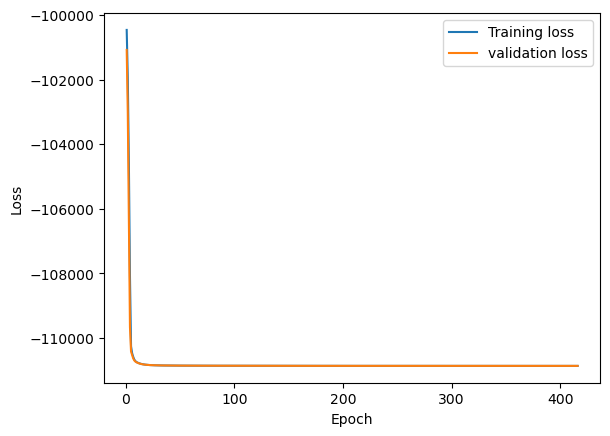

In [23]:
import numpy as np
import matplotlib.pyplot as plt

train_loss = np.array(NLE_inference.summary["training_loss"])
val_loss = np.array(NLE_inference.summary["validation_loss"])

epochs = np.arange(1, len(train_loss)+1)
log_train_loss = np.log10(train_loss)
log_val_loss = np.log10(val_loss)
log_epochs = np.log10(epochs)
#plt.figure()

plt.plot(epochs[50:], train_loss[50:], label="Training loss")
plt.plot(epochs[50:], val_loss[50:], label="validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
#plt.ylim(-112000, -100000)
plt.legend()
#plt.grid(True, which="both")

plt.show()

In [24]:
def standardize_plots(posterior_grid, posterior_sbi): 
    domega = Omega_vals[1] - Omega_vals[0]
    dalpha = alpha_vals[1] - alpha_vals[0]
    Z = np.sum(posterior_grid) * domega * dalpha
    posterior_grid_norm = posterior_grid / Z

    # marginalize over alpha
    p_omega = np.sum(posterior_grid, axis=1) * dalpha

    # marginalize over omega
    p_alpha = np.sum(posterior_grid, axis=0) * domega   

    
    log_probs = []

    for omega in Omega_vals:
        for alpha in alpha_vals:
            theta = torch.tensor([[omega, alpha]], dtype = torch.float32)
            lp = posterior_sbi.log_prob(theta, x=x_obs)
            log_probs.append(lp.item())

    log_probs = np.array(log_probs)

    log_probs -= np.max(log_probs)   # stabilize to exponentiate 

    sbi_grid = np.exp(log_probs)

    Z = np.sum(sbi_grid) * domega * dalpha
    sbi_grid /= Z
   
    print("Sum over grid (should be ≈1):", (np.sum(posterior_grid_norm) * domega * dalpha))
    print("Sum over sbi (should be ≈1):", (np.sum(sbi_grid) * domega * dalpha))
    num_samples = 2000
    grid_weights = posterior_grid.flatten()
    grid_idx = np.random.choice(len(grid_weights), size=num_samples, p=grid_weights/grid_weights.sum())

    A, O = np.meshgrid(alpha_vals, Omega_vals)
    samples_grid = np.column_stack((O.flatten()[grid_idx], A.flatten()[grid_idx]))  # (Ω, α)
    
    sbi_weights = sbi_grid.flatten()
    sbi_idx = np.random.choice(len(sbi_weights), size=num_samples, p=sbi_weights/sbi_weights.sum())
    samples_sbi = np.column_stack((O.flatten()[sbi_idx], A.flatten()[sbi_idx]))  # (Ω, α)

    return samples_grid, samples_sbi

In [25]:
samples_grid, samples_sbi = standardize_plots(grid_posterior, NLE_posterior)

/local/lexi.leali/ipykernel_1769837/3560931930.py:19: UserWarning: `.log_prob()` is deprecated for methods that can only evaluate the log-probability up to a normalizing constant. Use `.potential()` instead.
  lp = posterior_sbi.log_prob(theta, x=x_obs)
/local/lexi.leali/ipykernel_1769837/3560931930.py:19: UserWarning: The log-probability is unnormalized!
  lp = posterior_sbi.log_prob(theta, x=x_obs)


Sum over grid (should be ≈1): 1.0
Sum over sbi (should be ≈1): 1.0


In [26]:

# --- make DataFrame for plotting ---
df_grid = pd.DataFrame(samples_grid, columns=["Omega", "alpha"])
df_grid["source"] = "Grid"

In [27]:
# --- make DataFrame for plotting ---
df_NLE = pd.DataFrame(samples_sbi, columns=["Omega", "alpha"])
df_NLE["source"] = "NLE"

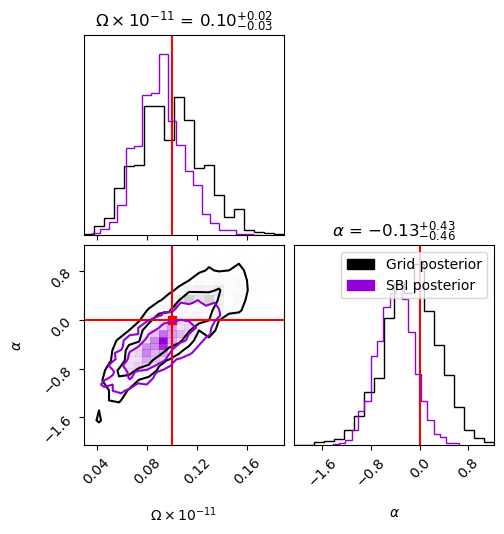

In [28]:
import matplotlib.colors as mcolors

# ----------------------------
# Corner plot
# ----------------------------
figure = corner.corner(
    df_grid[["Omega", "alpha"]].values,
    labels=[r"$\Omega \times 10^{-11}$", r"$\alpha$"],
    color="black",  # default color; we'll overlay SBI manually
    show_titles=True,
    title_kwargs={"fontsize": 12},
    truths=theta_true[0],
    truth_color="red",
    #range=([0.945, 2.5e-11], [0,3]),
    plot_datapoints=False,
    fill_contours=False,
    #contour_kwargs={"alpha":1, "colors":["C9"],"linestyles": ["-", "-."]},
    levels=(0.68, 0.95)#, 0.997
         # 
)

# Overlay SBI posterior samples in a different color
corner.corner(
    df_NLE[["Omega", "alpha"]].values,
    fig=figure,
    #labels=[r"$\Omega \times 10^{-11}$", r"$\alpha$"],
    color="darkviolet",
    plot_datapoints=False,
    fill_contours=False,
    #range=([0, 2.5e-11], [0,3]),
    #contour_kwargs={"alpha":0.6, "colors":["C1"], "linestyles": ["--", "-."]},
   # hist_kwargs={
   # "histtype": "step",
   # "linestyle": "-",       # dash-dot for SBI 1D marginal
   # "color": "C1",
    #"linewidth": 1
    #},
    levels=(0.68, 0.95), 
            #0.997
          # ),
)

# Add legend manually
import matplotlib.patches as mpatches
patch_grid = mpatches.Patch(color='black', label='Grid posterior')
patch_sbi  = mpatches.Patch(color='darkviolet', label='SBI posterior')
plt.legend(handles=[patch_grid, patch_sbi], loc='upper right')


### SBC

In [38]:
num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s
prior_samples = prior.sample((num_sbc_samples,))
prior_predictives = simulate_physical(prior_samples)

/local/lexi.leali/ipykernel_1769837/416138087.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_1769837/416138087.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)


/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)
/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/sbi/diagnostics/sbc.py:83: UserWarning: Using non-batched sampling. Depending on the number of different xs ( 200) and the number of parallel workers 1, this might take a lot of time.
  posterior_samples = get_posterior_samples_on_batch(
Sampling 200 times (300,) posterior samples.: 100%|█| 200/200 [5:02:59<00:00, 90
Calculating ranks for 200 SBC samples: 100%|█| 200/200 [00:00<00:00, 17407.00it/


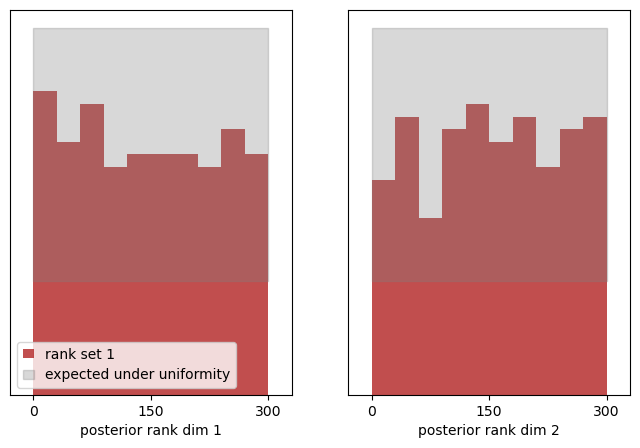

In [39]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot
 
NLE_posterior = NLE_inference.build_posterior()
num_posterior_samples = 300
ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictives,
    NLE_posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=num_posterior_samples,
    plot_type="hist",
    num_bins=None,  # by passing None we use a heuristic for the number of bins.
)

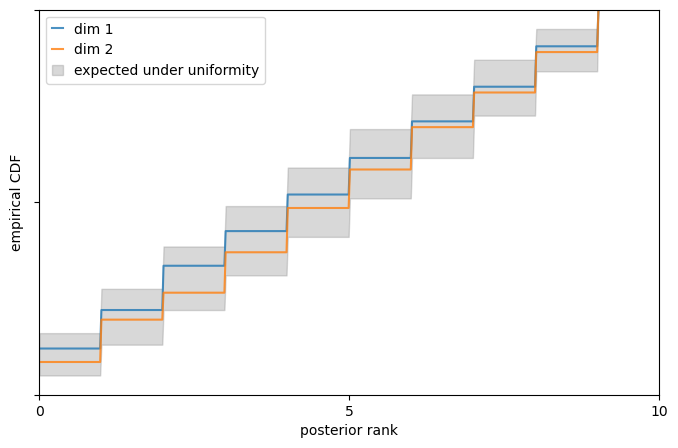

In [40]:
f, ax = sbc_rank_plot(ranks, 1_000, plot_type="cdf")

## Tests 

In [39]:
data = torch.load("simulated_observations.pt")


/local/lexi.leali/ipykernel_724531/2232072111.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("simulated_observations.pt")


In [40]:
thetas = data['theta']
x = data['x']

In [66]:
thetas.shape

torch.Size([10, 1, 2])


Test 1
True scaled omega: 0.9131602048873901
True alpha: 0.04205387085676193


/local/lexi.leali/ipykernel_1769837/416138087.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_1769837/416138087.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/416138087.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_true, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/4178284212.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionall

Sum over grid (should be ≈1): 1.0000000000000002
Sum over sbi (should be ≈1): 0.9999999999999999


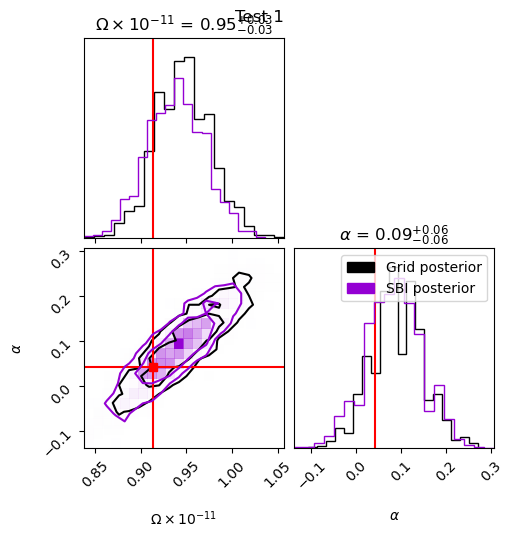


Test 2
True scaled omega: 0.39791151881217957
True alpha: 0.1812288612127304


/local/lexi.leali/ipykernel_1769837/416138087.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_1769837/416138087.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/416138087.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_true, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/4178284212.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionall

Sum over grid (should be ≈1): 0.9999999999999999
Sum over sbi (should be ≈1): 1.0


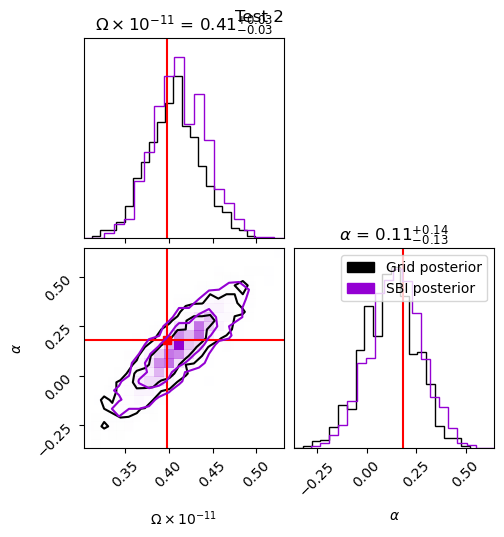


Test 3
True scaled omega: 0.8794500827789307
True alpha: 0.4537818133831024


/local/lexi.leali/ipykernel_1769837/416138087.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_1769837/416138087.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/416138087.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_true, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/4178284212.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionall

Sum over grid (should be ≈1): 0.9999999999999999
Sum over sbi (should be ≈1): 1.0


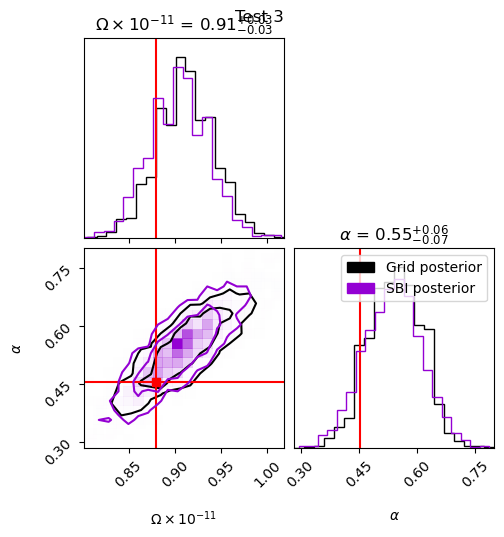


Test 4
True scaled omega: 0.8402971029281616
True alpha: -0.8990622758865356


/local/lexi.leali/ipykernel_1769837/416138087.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_1769837/416138087.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/416138087.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_true, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/4178284212.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionall

Sum over grid (should be ≈1): 1.0
Sum over sbi (should be ≈1): 0.9999999999999999


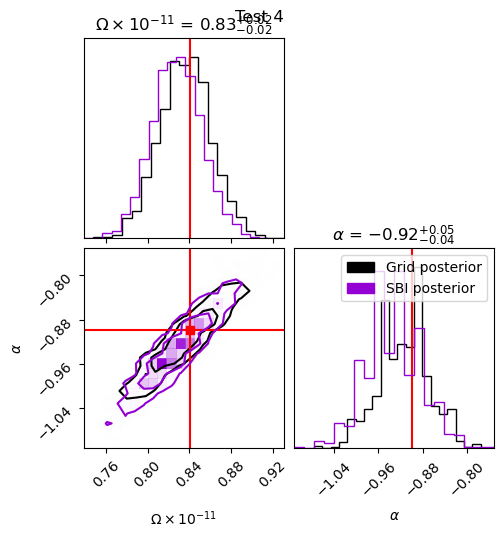


Test 5
True scaled omega: 1.1633050441741943
True alpha: 0.5990064144134521


/local/lexi.leali/ipykernel_1769837/416138087.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_1769837/416138087.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/416138087.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_true, dtype=torch.float32)
/local/lexi.leali/ipykernel_1769837/4178284212.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionall

Sum over grid (should be ≈1): 0.9999999999999999
Sum over sbi (should be ≈1): 1.0


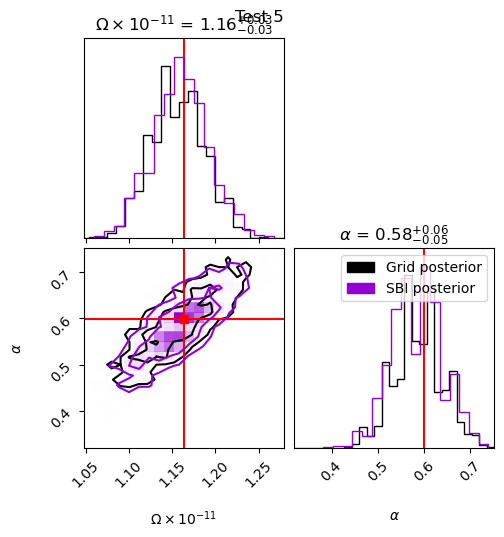

In [37]:
### import torch
import numpy as np
import matplotlib.pyplot as plt
import corner
import matplotlib.patches as mpatches
N_tests = 5
n_post_samples = 1000

for i in range(N_tests):

    # ------------------------------------------------
    # 1. Draw parameters from prior
    # ------------------------------------------------
    
    theta_true = prior.sample((1,))   # shape (1,2)

    omega_true = theta_true[0,0].item()
    alpha_true = theta_true[0,1].item()

    print(f"\nTest {i+1}")
    print("True scaled omega:", omega_true)
    print("True alpha:", alpha_true)

    # ------------------------------------------------
    # 2. Simulate observation
    # ------------------------------------------------

    x_obs = simulate_physical(theta_true)

    # ------------------------------------------------
    # 3. Posterior inference
    # ------------------------------------------------

    NLE_posterior.set_default_x(x_obs)
    grid_posterior = grid_eval(x_obs)

    samples = NLE_posterior.sample((n_post_samples,))

    samples_np = samples.detach().numpy()
    
    samples_grid, samples_sbi = standardize_plots(grid_posterior, NLE_posterior)

    
    # --- make DataFrame for plotting ---
    df_grid = pd.DataFrame(samples_grid, columns=["Omega", "alpha"])
    df_grid["source"] = "Grid"

    # --- make DataFrame for plotting ---
    df_NLE= pd.DataFrame(samples_sbi, columns=["Omega", "alpha"])
    df_NLE["source"] = "NLE"
    # ------------------------------------------------
    # 4. Plot posterior
    # ------------------------------------------------

    # ----------------------------
# Corner plot
# ----------------------------
    figure = corner.corner(
        df_grid[["Omega", "alpha"]].values,
        labels=[r"$\Omega \times 10^{-11}$", r"$\alpha$"],
        color="black",  # default color; we'll overlay SBI manually
        show_titles=True,
        #title_kwargs={"fontsize": 12},
        truths=theta_true[0],
        truth_color="red",
        #range=([0.945, 2.5e-11], [0,3]),
        plot_datapoints=False,
        fill_contours=False,
       # contour_kwargs={"alpha":1, "colors":["C9"],"linestyles": ["-", "-."]},
        levels=(0.68, 0.95)#, 0.997
         # 
    )
    # Overlay SBI posterior samples in a different color
    corner.corner(
        df_NLE[["Omega", "alpha"]].values,
        fig=figure,
        #labels=[r"$\Omega \times 10^{-11}$", r"$\alpha$"],
        color="darkviolet",
        plot_datapoints=False,
        fill_contours=False,
        #range=([0, 2.5e-11], [0,3]),
       # contour_kwargs={"alpha":0.6, "colors":["C1"], "linestyles": ["--", "-."]},
       # hist_kwargs={
       # "histtype": "step",
       # "linestyle": "-",       # dash-dot for SBI 1D marginal
        #"color": "C1",
      #  "linewidth": 1
      #  },
        levels=(0.68, 0.95), 
            #0.997
          # ),
    )
    # Add legend manually
    
    patch_grid = mpatches.Patch(color='black', label='Grid posterior')
    patch_sbi  = mpatches.Patch(color='darkviolet', label='SBI posterior')
    plt.legend(handles=[patch_grid, patch_sbi], loc='upper right')


    plt.suptitle(f"Test {i+1}")
    plt.show()

In [ ]:
### With the trained model, leave omega fixed and vary alpha

## Round Two 

In [ ]:
posterior = torch.load("NLE_posterior.pt")

In [143]:
likelihood_estimator = torch.load("likelihood_model.pt")

/local/lexi.leali/ipykernel_2373142/2898172240.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  likelihood_estimator = torch.load("likelihood_model.pt")


In [144]:
proposal = posterior.set_default_x(x_obs)

In [145]:
NLE_samples1 = proposal.sample((1_000,))  # draws from p(theta | x_obs)

Generating 20 MCMC inits via resample strategy: 100%|█| 20/20 [00:30<00:00,  1.5
Running vectorized MCMC with 20 chains: 100%|█| 6000/6000 [00:51<00:00, 116.46it


In [146]:
theta = torch.tensor([[ 1., -1.]])

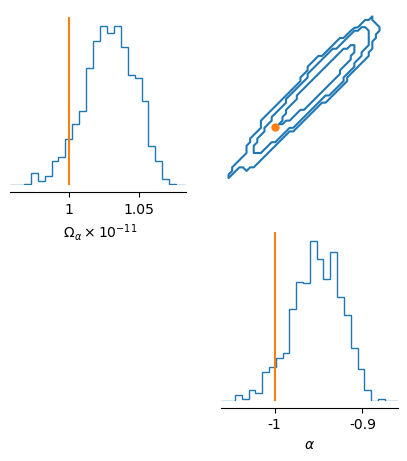

In [147]:

_ = pairplot(
    NLE_samples1, points = theta[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r" $\Omega_{\alpha} \times 10^{-11}$", r"$\alpha$"])

In [ ]:
proposal = NLE_posterior.set_default_x(x_obs)
M = 10#number of noise realizations for each theta
theta = proposal.sample((5000,))

x_all = []
theta_all = []

for theta_i in theta:

    x_multi = simulate_multi(theta_i, M)
    theta_rep = theta_i.repeat(M,1)

    x_all.append(x_multi)
    theta_all.append(theta_rep)

x_train = torch.vstack(x_all)
theta_all = torch.vstack(theta_all)


In [ ]:

density_estimator = NLE_inference.append_simulations(theta_all, x_train).train(validation_fraction = 0.2, 
                                                                     learning_rate = 1e-6,
                                                                                 # num_transforms = 6)
                       )


In [ ]:
posterior = NLE_inference.build_posterior(density_estimator)
proposal2 = posterior.set_default_x(x_obs)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

train_loss = np.array(NLE_inference.summary["training_loss"])
val_loss = np.array(NLE_inference.summary["validation_loss"])

epochs = np.arange(1, len(train_loss)+1)
log_train_loss = np.log10(train_loss)
log_val_loss = np.log10(val_loss)
log_epochs = np.log10(epochs)
#plt.figure()

plt.plot(epochs[247:], train_loss[247:], label="Training loss")
plt.plot(epochs[247:], val_loss[247:], label="validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
#plt.ylim(-112000, -100000)
plt.legend()
plt.grid(True, which="both")

plt.show()

In [ ]:
from sbi.analysis import plot_summary

# plot training loss
#_ = plot_summary(NLE_inference, tags=["training_loss", "validation_loss"], figsize=(10, 2))
# All training logs are available in `trainer.summary

In [ ]:
NLE_samples2 = proposal.sample((1_000,))  # draws from p(theta | x_obs)

In [ ]:
theta = torch.tensor([[ 0.003, 1.]])

In [ ]:

_ = pairplot(
    NLE_samples2, points = theta[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r" $\Omega_{\alpha} \times 10^{-11}$", r"$\alpha$"])

In [ ]:
# ----------------------------
# Corner plot
# ----------------------------
figure = corner.corner(
    df_round1[["Omega", "alpha"]].values,
    labels=["Ω", "α"],
    color="C9",  # default color; we'll overlay SBI manually
    show_titles=True,
    title_kwargs={"fontsize": 12},
    #truths=theta_true[0],
    truth_color="red",
    #range=([0.945, 2.5e-11], [0,3]),
    plot_datapoints=False,
    fill_contours=False,
    contour_kwargs={"alpha":1, "colors":["C9"],"linestyles": ["-", "-."]},
    levels=(0.68, 0.95)#, 0.997
         # 
)
"""
# Overlay SBI posterior samples in a different color
corner.corner(
    df_NLE[["Omega", "alpha"]].values,
    fig=figure,
    color="C1",
    plot_datapoints=False,
    fill_contours=True,
    #range=([0, 2.5e-11], [0,3]),
    contour_kwargs={"alpha":0.6, "colors":["C1"], "linestyles": ["--", "-."]},
    hist_kwargs={
    "histtype": "step",
    "linestyle": "-",       # dash-dot for SBI 1D marginal
    "color": "C1",
    "linewidth": 1
    },
    levels=(0.68, 0.95), 
            #0.997
          # ),
)
"""
# Add legend manually
import matplotlib.patches as mpatches
patch_grid = mpatches.Patch(color='C9', label='Grid posterior')
patch_sbi  = mpatches.Patch(color='C1', label='SBI posterior')
plt.legend(handles=[patch_grid, patch_sbi], loc='upper right')

